<a href="https://colab.research.google.com/github/europecodingschool/ECS---VB---YZ---08.26/blob/main/VB_YZ_Ders_15_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
veri = pd.read_csv("/content/ucak_bileti.csv")

In [5]:
veri.head()

,rota,havayolu,aktarma,ucus_suresi_dk,kalan_gun,kalkis_dilimi,ucus_gunu,bayram_donemi,bagaj_dahil,doluluk_orani,arama_cihazi,fiyat_tl
0,ANK-IZM,Kanat,0,72,3,Ogle,Cuma,0,0,0.90,Mobil,4310
1,IST-ANT,Bulut,0,85,65,Aksam,Hafta ici,0,1,0.71,Mobil,2740
2,IZM-ANT,Zirve,0,61,19,Sabah,Pazar,0,1,0.61,Masaustu,2790
3,IST-VAN,Zirve,0,136,64,Sabah,Hafta ici,1,0,0.54,Masaustu,6050
4,IST-ANK,Kanat,0,77,51,Ogle,Hafta ici,0,0,0.45,Mobil,1390


Senaryomuz ve hedef:
**kalın metin**

Alacağın bu bilet pahalı mı ucuz mu ve olması gereken fiyatını tahmin etme yoluna gidebiliriz.


In [7]:
veri.shape

(2500, 12)

In [9]:
veri.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   rota            2500 non-null   object 
 1   havayolu        2500 non-null   object 
 2   aktarma         2500 non-null   int64  
 3   ucus_suresi_dk  2500 non-null   int64  
 4   kalan_gun       2500 non-null   int64  
 5   kalkis_dilimi   2500 non-null   object 
 6   ucus_gunu       2500 non-null   object 
 7   bayram_donemi   2500 non-null   int64  
 8   bagaj_dahil     2500 non-null   int64  
 9   doluluk_orani   2500 non-null   float64
 10  arama_cihazi    2500 non-null   object 
 11  fiyat_tl        2500 non-null   int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 234.5+ KB


In [11]:
veri.isnull().sum()

,0
rota,0
havayolu,0
aktarma,0
ucus_suresi_dk,0
kalan_gun,0
kalkis_dilimi,0
ucus_gunu,0
bayram_donemi,0
bagaj_dahil,0
doluluk_orani,0


In [14]:
veri.describe().round(2)

,aktarma,ucus_suresi_dk,kalan_gun,bayram_donemi,bagaj_dahil,doluluk_orani,fiyat_tl
count,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00
mean,0.19,106.62,45.33,0.08,0.47,0.66,2440.22
std,0.39,60.10,26.23,0.27,0.50,0.16,1048.97
min,0.00,55.00,0.00,0.00,0.00,0.20,910.00
25%,0.00,69.00,22.00,0.00,0.00,0.55,1770.00
50%,0.00,79.00,46.00,0.00,0.00,0.68,2200.00
75%,0.00,116.00,68.00,0.00,1.00,0.79,2800.00
max,1.00,334.00,90.00,1.00,1.00,0.98,13430.00


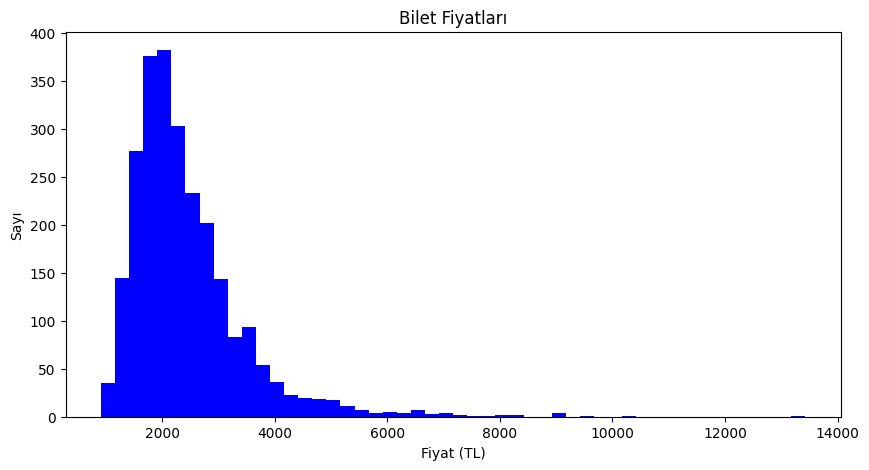

In [16]:
#Bilet fiyatlarının dağılımı histogram.

plt.figure(figsize=(10,5))
plt.hist(veri["fiyat_tl"], bins=50, color="b")
plt.title("Bilet Fiyatları")
plt.xlabel("Fiyat (TL)")
plt.ylabel("Sayı")
plt.show()


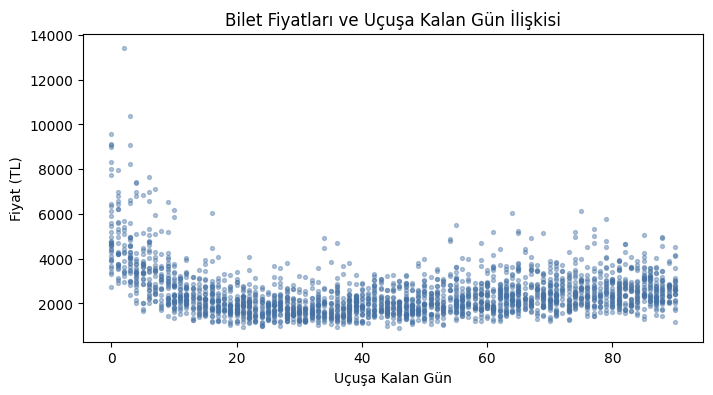

In [20]:
# UÇAŞA KALAN GÜN ve FİYAT İLİŞKİSİ

plt.figure(figsize=(8,4))
plt.scatter(veri["kalan_gun"], veri["fiyat_tl"], color="#4671A3", s=8, alpha=0.4)
plt.title("Bilet Fiyatları ve Uçuşa Kalan Gün İlişkisi")
plt.xlabel("Uçuşa Kalan Gün")
plt.ylabel("Fiyat (TL)")
plt.show()

In [24]:
havayolu_ortalama = veri.groupby("havayolu")["fiyat_tl"].mean().round(0)
print(havayolu_ortalama)

havayolu
Bulut    2368.0
Kanat    2160.0
Zirve    3032.0
Name: fiyat_tl, dtype: float64


In [26]:
rota_ortalama = veri.groupby("rota")["fiyat_tl"].mean().round(0)
print(rota_ortalama)

rota
ANK-IZM    2370.0
ANK-TZX    2383.0
IST-ANK    2310.0
IST-ANT    2417.0
IST-IZM    2292.0
IST-TZX    2802.0
IST-VAN    3141.0
IZM-ANT    2443.0
Name: fiyat_tl, dtype: float64


In [29]:
bayram_ortalama = veri.groupby("bayram_donemi")["fiyat_tl"].mean().round(0)
print(bayram_ortalama)
#

bayram_donemi
0    2320.0
1    3874.0
Name: fiyat_tl, dtype: float64


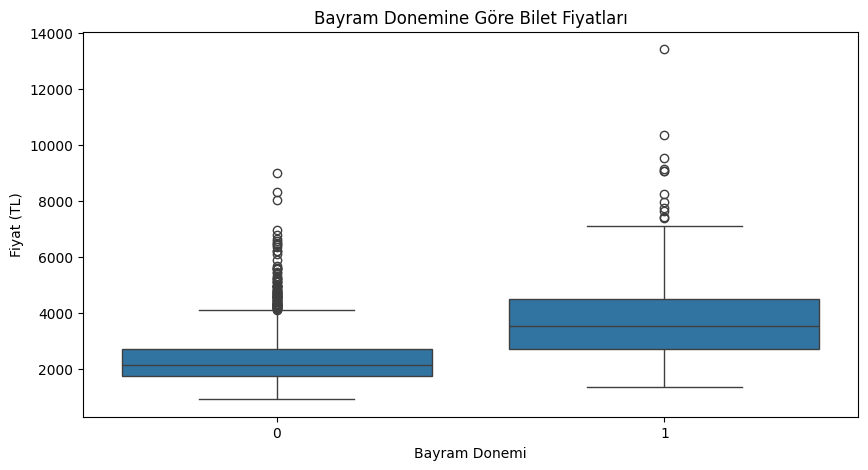

In [32]:
plt.figure(figsize=(10,5))
sns.boxplot(data=veri, x="bayram_donemi", y="fiyat_tl")
plt.title("Bayram Donemine Göre Bilet Fiyatları")
plt.xlabel("Bayram Donemi")
plt.ylabel("Fiyat (TL)")
plt.show()